# Artefato A05 - CNN Simples

Este notebook reorganiza o A05 para a entrega final usando apenas os artefatos consolidados do repositorio.

Fontes principais da narrativa e do codigo:
- `notebooks/final/exploracao_sentinel2_long.ipynb`
- `notebooks/final/exploracao_landsat89_long.ipynb`
- `notebooks/final/exploracao_modis_long.ipynb`
- `notebooks/final/exploracao_compilada_satelites_long.ipynb`
- `outputs/final/`

Escopo do artefato:
1. Documentar a preparacao dos dados para a CNN simples por sensor.
2. Mostrar a arquitetura realmente usada nos resultados finais salvos.
3. Consolidar treino, validacao e diagnostico de overfitting.
4. Avaliar quantitativamente as CNNs e compara-las ao baseline MLP da Sprint 2.
5. Fechar com uma analise critica guiada pelos notebooks exploratorios finais.

## 1) Setup

O notebook foi estruturado para executar apenas com os arquivos ja exportados em `outputs/final`, sem depender dos parquet originais nem de TensorFlow.

In [1]:
from pathlib import Path
import json
import os
import sys

os.environ.setdefault("MPLCONFIGDIR", str((Path.cwd() / ".mplconfig").resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
except Exception:
    sns = None

try:
    from IPython.display import Markdown, display
except Exception:
    def display(obj):
        print(obj)

    def Markdown(text):
        return text


def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    if (cwd / "src").exists() and (cwd / "notebooks").exists():
        return cwd
    for parent in [cwd, *cwd.parents]:
        if (parent / "src").exists() and (parent / "notebooks").exists():
            return parent
    raise FileNotFoundError("Nao foi possivel localizar a raiz do projeto.")


PROJECT_ROOT = resolve_project_root()
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "final"
CNN_DIR = OUTPUT_DIR / "a05_cnn_multissatelite"
NOTEBOOKS_FINAL_DIR = PROJECT_ROOT / "notebooks" / "final"

SENSOR_ORDER = ["sentinel2", "landsat89", "modis"]
SENSOR_NAMES = {
    "sentinel2": "Sentinel-2",
    "landsat89": "Landsat 8/9",
    "modis": "MODIS",
}
CLASS_NAMES = ["Negativo (0)", "Positivo (1)"]

if sns is not None:
    sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)

source_notebooks = [
    NOTEBOOKS_FINAL_DIR / "exploracao_sentinel2_long.ipynb",
    NOTEBOOKS_FINAL_DIR / "exploracao_landsat89_long.ipynb",
    NOTEBOOKS_FINAL_DIR / "exploracao_modis_long.ipynb",
    NOTEBOOKS_FINAL_DIR / "exploracao_compilada_satelites_long.ipynb",
]

required_outputs = [
    OUTPUT_DIR / "compilado_overview.csv",
    OUTPUT_DIR / "compilado_hipoteses.txt",
    OUTPUT_DIR / "sentinel2_overview.json",
    OUTPUT_DIR / "landsat89_overview.json",
    OUTPUT_DIR / "modis_overview.json",
    CNN_DIR / "cnn_multissatelite_comparison.csv",
    CNN_DIR / "cnn_multissatelite_analysis.txt",
]

status_rows = []
for path in source_notebooks + required_outputs:
    try:
        rel = path.relative_to(PROJECT_ROOT)
    except ValueError:
        rel = path
    status_rows.append({"arquivo": str(rel), "existe": path.exists()})

status_df = pd.DataFrame(status_rows)
display(status_df)

print(f"Projeto: {PROJECT_ROOT}")
print(f"Saida final: {OUTPUT_DIR}")

Projeto: /Users/giovanna-britto/Documents/INTELI/PROJETO/g01
Saida final: /Users/giovanna-britto/Documents/INTELI/PROJETO/g01/outputs/final


,arquivo,existe
0,notebooks/final/exploracao_sentinel2_long.ipynb,True
1,notebooks/final/exploracao_landsat89_long.ipynb,True
2,notebooks/final/exploracao_modis_long.ipynb,True
3,notebooks/final/exploracao_compilada_satelites...,True
4,outputs/final/compilado_overview.csv,True
5,outputs/final/compilado_hipoteses.txt,True
6,outputs/final/sentinel2_overview.json,True
7,outputs/final/landsat89_overview.json,True
8,outputs/final/modis_overview.json,True
9,outputs/final/a05_cnn_multissatelite/cnn_multi...,True


## 2) Carregamento dos artefatos

O padrao de carregamento reaproveita a logica dos notebooks finais de exploracao: cada sensor possui um conjunto de artefatos tabulares (`overview`, `band_summary`, `index_summary`, `hypotheses`, `image_counts`) e, para a etapa de CNN, um segundo conjunto com preparacao, arquitetura, historico, metricas e matriz de confusao.

In [2]:
def read_json(path: Path) -> dict:
    with path.open("r", encoding="utf-8") as fp:
        return json.load(fp)


def read_csv(path: Path) -> pd.DataFrame:
    return pd.read_csv(path)


def read_lines(path: Path) -> list[str]:
    return [line.strip() for line in path.read_text(encoding="utf-8").splitlines() if line.strip()]


def load_sensor_artifacts(sensor_key: str) -> dict:
    sensor_dir = CNN_DIR / sensor_key
    data = {
        "sensor_key": sensor_key,
        "sensor_name": SENSOR_NAMES[sensor_key],
        "overview": read_json(OUTPUT_DIR / f"{sensor_key}_overview.json"),
        "band_summary": read_csv(OUTPUT_DIR / f"{sensor_key}_band_summary.csv"),
        "index_summary": read_csv(OUTPUT_DIR / f"{sensor_key}_index_summary.csv"),
        "hypotheses": read_lines(OUTPUT_DIR / f"{sensor_key}_hypotheses.txt"),
        "image_counts": read_csv(OUTPUT_DIR / f"{sensor_key}_image_counts.csv"),
        "data_prep": read_json(sensor_dir / "data_prep_summary.json"),
        "architecture": read_json(sensor_dir / "architecture_summary.json"),
        "split": read_json(sensor_dir / "split_summary.json"),
        "history": read_csv(sensor_dir / "history.csv"),
        "metrics": read_json(sensor_dir / "metrics_test.json"),
        "confusion": read_csv(sensor_dir / "confusion_matrix.csv"),
    }
    return data


artifacts = {sensor_key: load_sensor_artifacts(sensor_key) for sensor_key in SENSOR_ORDER}
comparison_df = read_csv(CNN_DIR / "cnn_multissatelite_comparison.csv")
analysis_lines = read_lines(CNN_DIR / "cnn_multissatelite_analysis.txt")
compiled_overview_df = read_csv(OUTPUT_DIR / "compilado_overview.csv")
compiled_hypotheses = read_lines(OUTPUT_DIR / "compilado_hipoteses.txt")

artifact_status_rows = []
for sensor_key in SENSOR_ORDER:
    item = artifacts[sensor_key]
    artifact_status_rows.append(
        {
            "sensor": item["sensor_name"],
            "overview_ok": item["overview"] is not None,
            "band_summary_rows": len(item["band_summary"]),
            "index_summary_rows": len(item["index_summary"]),
            "hypotheses": len(item["hypotheses"]),
            "history_epochs": len(item["history"]),
            "confusion_shape": tuple(item["confusion"].shape),
        }
    )

artifact_status_df = pd.DataFrame(artifact_status_rows)
display(artifact_status_df)

,sensor,overview_ok,band_summary_rows,index_summary_rows,hypotheses,history_epochs,confusion_shape
0,Sentinel-2,True,12,4,4,11,"(2, 2)"
1,Landsat 8/9,True,7,4,4,28,"(2, 2)"
2,MODIS,True,7,4,4,13,"(2, 2)"


## 3) Fontes e escopo da consolidacao

O papel dos notebooks finais foi dividido em duas camadas:
- os notebooks exploratorios por sensor explicam o comportamento espectral e exportam os artefatos de contexto;
- o notebook compilado dos sensores sintetiza comparacoes e hipoteses globais;
- os resultados de `outputs/final/a05_cnn_multissatelite/` entram aqui como evidencia final de modelagem e avaliacao.

Observacao metodologica importante: nao ha, dentro de `notebooks/final`, um notebook correspondente ao treino da CNN multissatellite. Por isso, os arquivos em `outputs/final/a05_cnn_multissatelite/` sao tratados como artefatos finais importados.

,fonte,papel,artefatos_reaproveitados
0,exploracao_sentinel2_long.ipynb,"EDA do sensor, bandas, indices, imagens e hipo...",sentinel2_overview.json; sentinel2_band_summar...
1,exploracao_landsat89_long.ipynb,"EDA do sensor, bandas, indices, imagens e hipo...",landsat89_overview.json; landsat89_band_summar...
2,exploracao_modis_long.ipynb,"EDA do sensor, bandas, indices, imagens e hipo...",modis_overview.json; modis_band_summary.csv; m...
3,exploracao_compilada_satelites_long.ipynb,Comparacao entre sensores e consolidacao de hi...,compilado_overview.csv; compilado_hipoteses.txt
4,outputs/final/a05_cnn_multissatelite/,"Resultados finais de treino, avaliacao e compa...",data_prep_summary.json; architecture_summary.j...


,sensor_key,sensor,n_rows_total,n_rows_analysis,n_bands,n_images
0,landsat89,Landsat 8/9,105977560,105977560,7,1532
1,modis,MODIS,109016100,109016100,7,1575
2,sentinel2,Sentinel-2,93963765,93963765,12,1356


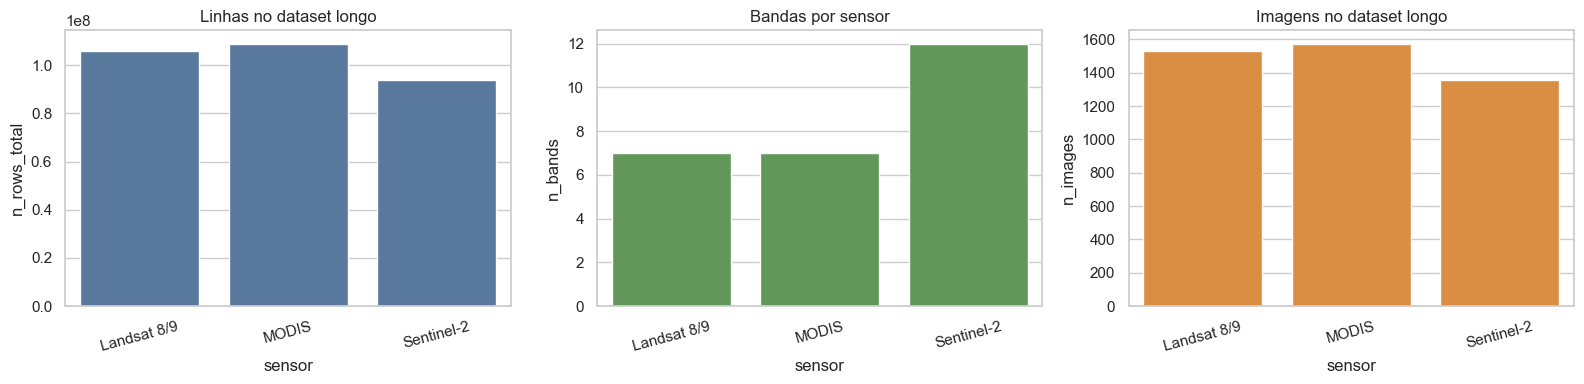

In [3]:
source_map_df = pd.DataFrame(
    [
        {
            "fonte": "exploracao_sentinel2_long.ipynb",
            "papel": "EDA do sensor, bandas, indices, imagens e hipoteses",
            "artefatos_reaproveitados": "sentinel2_overview.json; sentinel2_band_summary.csv; sentinel2_index_summary.csv; sentinel2_hypotheses.txt; sentinel2_image_counts.csv",
        },
        {
            "fonte": "exploracao_landsat89_long.ipynb",
            "papel": "EDA do sensor, bandas, indices, imagens e hipoteses",
            "artefatos_reaproveitados": "landsat89_overview.json; landsat89_band_summary.csv; landsat89_index_summary.csv; landsat89_hypotheses.txt; landsat89_image_counts.csv",
        },
        {
            "fonte": "exploracao_modis_long.ipynb",
            "papel": "EDA do sensor, bandas, indices, imagens e hipoteses",
            "artefatos_reaproveitados": "modis_overview.json; modis_band_summary.csv; modis_index_summary.csv; modis_hypotheses.txt; modis_image_counts.csv",
        },
        {
            "fonte": "exploracao_compilada_satelites_long.ipynb",
            "papel": "Comparacao entre sensores e consolidacao de hipoteses",
            "artefatos_reaproveitados": "compilado_overview.csv; compilado_hipoteses.txt",
        },
        {
            "fonte": "outputs/final/a05_cnn_multissatelite/",
            "papel": "Resultados finais de treino, avaliacao e comparacao com MLP",
            "artefatos_reaproveitados": "data_prep_summary.json; architecture_summary.json; history.csv; metrics_test.json; confusion_matrix.csv; cnn_multissatelite_comparison.csv",
        },
    ]
)
display(source_map_df)

overview_df = compiled_overview_df.copy()
overview_df["sensor"] = overview_df["sensor_key"].map(SENSOR_NAMES)
overview_df = overview_df[
    ["sensor_key", "sensor", "n_rows_total", "n_rows_analysis", "n_bands", "n_images"]
].sort_values("sensor", ignore_index=True)
display(overview_df)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
plot_df = overview_df.sort_values("sensor")

if sns is not None:
    sns.barplot(data=plot_df, x="sensor", y="n_rows_total", ax=axes[0], color="#4C78A8")
    sns.barplot(data=plot_df, x="sensor", y="n_bands", ax=axes[1], color="#59A14F")
    sns.barplot(data=plot_df, x="sensor", y="n_images", ax=axes[2], color="#F28E2B")
else:
    axes[0].bar(plot_df["sensor"], plot_df["n_rows_total"], color="#4C78A8")
    axes[1].bar(plot_df["sensor"], plot_df["n_bands"], color="#59A14F")
    axes[2].bar(plot_df["sensor"], plot_df["n_images"], color="#F28E2B")

axes[0].set_title("Linhas no dataset longo")
axes[1].set_title("Bandas por sensor")
axes[2].set_title("Imagens no dataset longo")
for ax in axes:
    ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

## 4) Preparacao dos dados para CNN

A exploracao final mostra o contexto em formato longo por pixel. Para a CNN simples, a unidade de entrada passa a ser a imagem/tile rotulada por sensor.

Convencoes assumidas nesta consolidacao:
- `label = 0` representa a classe negativa;
- `label = 1` representa a classe positiva;
- cada imagem rotulada e convertida em um tensor `H x W x C`;
- a preparacao final foi salva por sensor em `outputs/final/a05_cnn_multissatelite/*/data_prep_summary.json`.

,sensor,n_rows_dataset_longo,n_images_dataset_longo,pixels_por_imagem_mediana_longo,pixels_por_imagem_max_longo,n_images_rotuladas,tensor_shape,height,width,n_bands,classe_0_negativa,classe_1_positiva,n_train,n_val,n_test
0,Landsat 8/9,105977560,1532,69390.0,71208,255,255 x 257 x 270 x 7,257,270,7,85,170,178,38,39
1,MODIS,109016100,1575,69390.0,71208,430,430 x 257 x 270 x 7,257,270,7,110,320,301,64,65
2,Sentinel-2,93963765,1356,69402.0,71208,212,212 x 257 x 270 x 12,257,270,12,62,150,148,32,32


,sensor,split,negativo_0,positivo_1
0,Sentinel-2,train,43,105
1,Sentinel-2,val,9,23
2,Sentinel-2,test,10,22
3,Landsat 8/9,train,59,119
4,Landsat 8/9,val,13,25
5,Landsat 8/9,test,13,26
6,MODIS,train,77,224
7,MODIS,val,16,48
8,MODIS,test,17,48


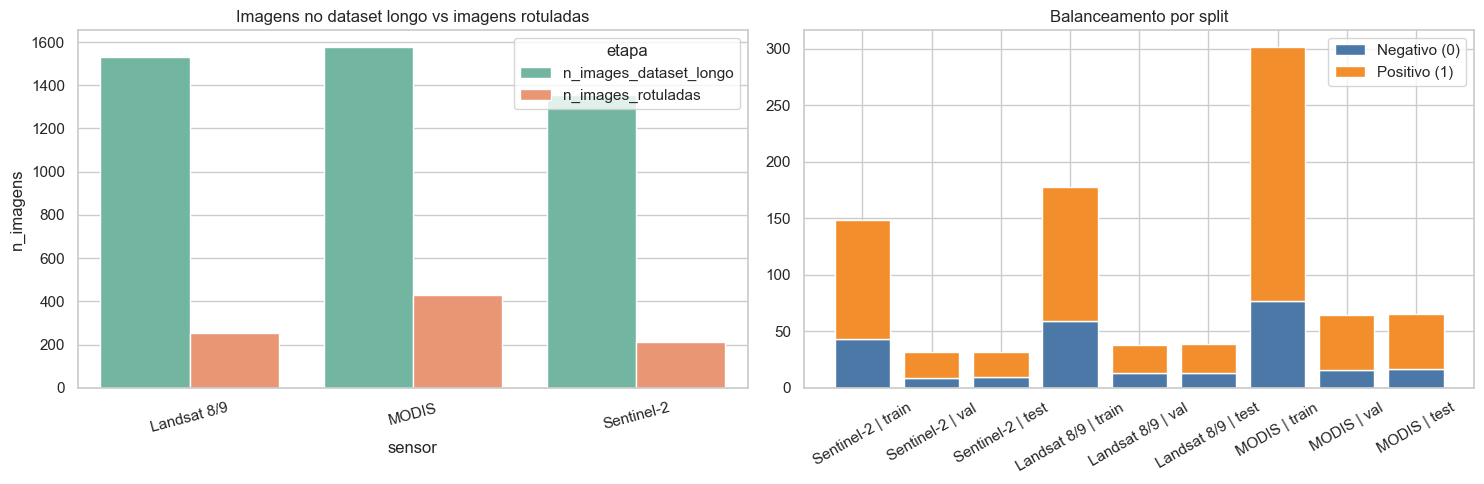

- Todos os sensores foram convertidos para tiles com shape espacial fixo de `257 x 270`, totalizando 69390 pixels por imagem.
- A etapa de rotulacao reduz o universo de imagens, saindo do dataset longo completo para o subconjunto efetivamente usado na CNN.
- Os arquivos `*_image_counts.csv` mostram o volume por imagem no dataset longo e ajudam a explicitar a passagem da granularidade de cena para a granularidade do tile usado na CNN.
- Em todos os sensores, a classe positiva domina o conjunto rotulado, o que ajuda a explicar a maior sensibilidade do que especificidade nas avaliacoes finais.
- Sentinel-2 muda apenas no numero de canais de entrada (12), enquanto Landsat 8/9 e MODIS operam com 7 bandas.

In [4]:
prep_rows = []
split_rows = []
for sensor_key in SENSOR_ORDER:
    item = artifacts[sensor_key]
    prep = item["data_prep"]
    split = item["split"]
    prep_rows.append(
        {
            "sensor": item["sensor_name"],
            "n_rows_dataset_longo": item["overview"]["n_rows_total"],
            "n_images_dataset_longo": item["overview"]["n_images"],
            "pixels_por_imagem_mediana_longo": float(item["image_counts"]["n_pixels"].median()),
            "pixels_por_imagem_max_longo": int(item["image_counts"]["n_pixels"].max()),
            "n_images_rotuladas": prep["n_images_after_label_filter"],
            "tensor_shape": " x ".join(str(v) for v in prep["tensor_shape"]),
            "height": prep["height"],
            "width": prep["width"],
            "n_bands": prep["n_bands"],
            "classe_0_negativa": prep["class_balance"].get("0", 0),
            "classe_1_positiva": prep["class_balance"].get("1", 0),
            "n_train": split["n_train"],
            "n_val": split["n_val"],
            "n_test": split["n_test"],
        }
    )
    for split_name, key in [("train", "class_balance_train"), ("val", "class_balance_val"), ("test", "class_balance_test")]:
        split_rows.append(
            {
                "sensor": item["sensor_name"],
                "split": split_name,
                "negativo_0": split[key].get("0", 0),
                "positivo_1": split[key].get("1", 0),
            }
        )

prep_summary_df = pd.DataFrame(prep_rows).sort_values("sensor", ignore_index=True)
split_balance_df = pd.DataFrame(split_rows)

display(prep_summary_df)
display(split_balance_df)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
image_view = prep_summary_df.melt(
    id_vars="sensor",
    value_vars=["n_images_dataset_longo", "n_images_rotuladas"],
    var_name="etapa",
    value_name="n_imagens",
)
if sns is not None:
    sns.barplot(data=image_view, x="sensor", y="n_imagens", hue="etapa", ax=axes[0], palette="Set2")
else:
    pivot = image_view.pivot(index="sensor", columns="etapa", values="n_imagens")
    pivot.plot(kind="bar", ax=axes[0])
axes[0].set_title("Imagens no dataset longo vs imagens rotuladas")
axes[0].tick_params(axis="x", rotation=15)

stacked_balance = split_balance_df.copy()
stacked_balance["total"] = stacked_balance["negativo_0"] + stacked_balance["positivo_1"]
balance_plot_df = stacked_balance.copy()
balance_plot_df["sensor_split"] = balance_plot_df["sensor"] + " | " + balance_plot_df["split"]
axes[1].bar(balance_plot_df["sensor_split"], balance_plot_df["negativo_0"], label="Negativo (0)", color="#4C78A8")
axes[1].bar(
    balance_plot_df["sensor_split"],
    balance_plot_df["positivo_1"],
    bottom=balance_plot_df["negativo_0"],
    label="Positivo (1)",
    color="#F28E2B",
)
axes[1].set_title("Balanceamento por split")
axes[1].tick_params(axis="x", rotation=30)
axes[1].legend()
plt.tight_layout()
plt.show()

prep_insights = [
    f"- Todos os sensores foram convertidos para tiles com shape espacial fixo de `257 x 270`, totalizando {artifacts['sentinel2']['data_prep']['target_pixels']} pixels por imagem.",
    "- A etapa de rotulacao reduz o universo de imagens, saindo do dataset longo completo para o subconjunto efetivamente usado na CNN.",
    "- Os arquivos `*_image_counts.csv` mostram o volume por imagem no dataset longo e ajudam a explicitar a passagem da granularidade de cena para a granularidade do tile usado na CNN.",
    "- Em todos os sensores, a classe positiva domina o conjunto rotulado, o que ajuda a explicar a maior sensibilidade do que especificidade nas avaliacoes finais.",
    "- Sentinel-2 muda apenas no numero de canais de entrada (12), enquanto Landsat 8/9 e MODIS operam com 7 bandas.",
]
display(Markdown("\n".join(prep_insights)))

## 5) Implementacao da arquitetura CNN

A arquitetura final preserva a ideia de uma **CNN simples**: dois blocos convolucionais com `Dropout` e `MaxPooling`, seguidos por `Flatten`, uma camada densa intermediaria e uma saida binaria com duas unidades.

O que muda entre sensores e apenas a profundidade da entrada (`C`), o que afeta a primeira convolucao e o numero total de parametros.

,sensor,input_shape,total_params,trainable_params,primeira_conv_params,dense_hidden_params,n_camadas,sequencia
0,Landsat 8/9,"(257, 270, 7)",35148226,35148226,2048,35127424,10,Conv2D -> Dropout -> MaxPooling2D -> Conv2D ->...
1,MODIS,"(257, 270, 7)",35148226,35148226,2048,35127424,10,Conv2D -> Dropout -> MaxPooling2D -> Conv2D ->...
2,Sentinel-2,"(257, 270, 12)",35149666,35149666,3488,35127424,10,Conv2D -> Dropout -> MaxPooling2D -> Conv2D ->...


,sensor,ordem,layer_name,layer_type,output_shape,params
0,Sentinel-2,1,conv2d_1,Conv2D,"(None, 257, 270, 32)",3488
1,Sentinel-2,2,dropout_conv1,Dropout,"(None, 257, 270, 32)",0
2,Sentinel-2,3,maxpooling2d_1,MaxPooling2D,"(None, 128, 135, 32)",0
3,Sentinel-2,4,conv2d_2,Conv2D,"(None, 128, 135, 64)",18496
4,Sentinel-2,5,dropout_conv2,Dropout,"(None, 128, 135, 64)",0
5,Sentinel-2,6,maxpooling2d_2,MaxPooling2D,"(None, 64, 67, 64)",0
6,Sentinel-2,7,flatten,Flatten,"(None, 274432)",0
7,Sentinel-2,8,dense_hidden,Dense,"(None, 128)",35127424
8,Sentinel-2,9,dropout_dense,Dropout,"(None, 128)",0
9,Sentinel-2,10,output,Dense,"(None, 2)",258


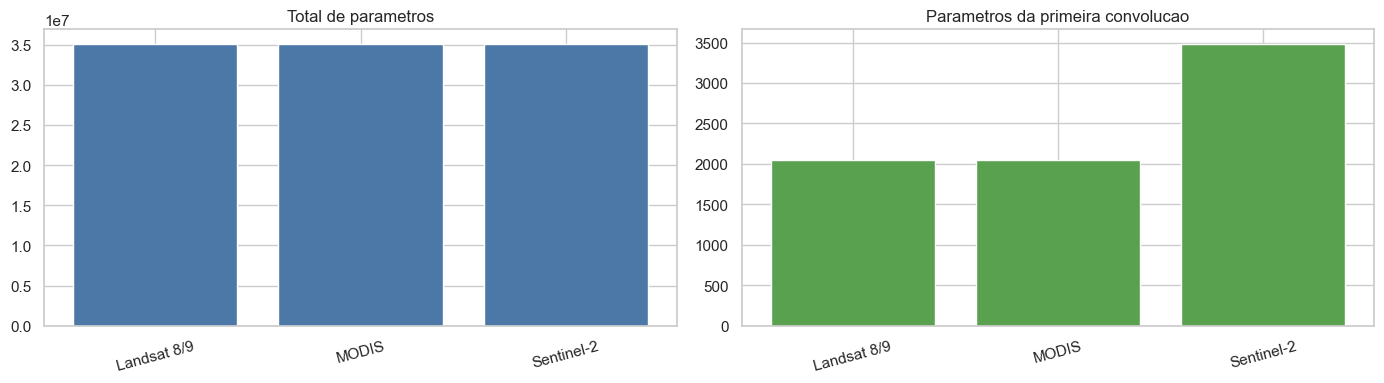

- A sequencia de camadas e a mesma nos tres sensores, o que preserva a interpretacao de baseline simples.
- O grosso da complexidade fica na combinacao `Flatten -> Dense(128)`, com mais de 35 milhoes de parametros.
- Sentinel-2 tem ligeiro aumento de parametros porque entra com 12 bandas em vez de 7.

In [5]:
architecture_rows = []
layer_rows = []
for sensor_key in SENSOR_ORDER:
    item = artifacts[sensor_key]
    arch = item["architecture"]
    layers = arch["layers_info"]
    first_conv = next(layer for layer in layers if layer["type"] == "Conv2D")
    dense_hidden = next(layer for layer in layers if layer["name"] == "dense_hidden")
    architecture_rows.append(
        {
            "sensor": item["sensor_name"],
            "input_shape": tuple(item["metrics"]["input_shape"]),
            "total_params": arch["total_params"],
            "trainable_params": arch["trainable_params"],
            "primeira_conv_params": first_conv["params"],
            "dense_hidden_params": dense_hidden["params"],
            "n_camadas": len(layers),
            "sequencia": " -> ".join(layer["type"] for layer in layers),
        }
    )
    for idx, layer in enumerate(layers, start=1):
        layer_rows.append(
            {
                "sensor": item["sensor_name"],
                "ordem": idx,
                "layer_name": layer["name"],
                "layer_type": layer["type"],
                "output_shape": tuple(layer["output_shape"]) if layer.get("output_shape") else None,
                "params": layer["params"],
            }
        )

architecture_df = pd.DataFrame(architecture_rows).sort_values("sensor", ignore_index=True)
architecture_layers_df = pd.DataFrame(layer_rows)

display(architecture_df)
display(architecture_layers_df.head(15))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(architecture_df["sensor"], architecture_df["total_params"], color="#4C78A8")
axes[0].set_title("Total de parametros")
axes[0].tick_params(axis="x", rotation=15)

axes[1].bar(architecture_df["sensor"], architecture_df["primeira_conv_params"], color="#59A14F")
axes[1].set_title("Parametros da primeira convolucao")
axes[1].tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

architecture_notes = [
    "- A sequencia de camadas e a mesma nos tres sensores, o que preserva a interpretacao de baseline simples.",
    "- O grosso da complexidade fica na combinacao `Flatten -> Dense(128)`, com mais de 35 milhoes de parametros.",
    "- Sentinel-2 tem ligeiro aumento de parametros porque entra com 12 bandas em vez de 7.",
]
display(Markdown("\n".join(architecture_notes)))

## 6) Treinamento e validacao do modelo

O treinamento salvo em `outputs/final/a05_cnn_multissatelite/*/history.csv` permite reconstruir as curvas de `loss`, `accuracy` e o gap de generalizacao sem rerodar a CNN.

,sensor,epochs_ran,best_epoch_val_acc,best_val_acc,best_epoch_val_loss,best_val_loss,final_train_acc,final_val_acc,gap_train_minus_val_acc
0,Landsat 8/9,28,13,0.842105,20,0.982496,0.938202,0.789474,0.148729
1,MODIS,13,1,0.890625,5,1.107429,0.956811,0.421875,0.534936
2,Sentinel-2,11,5,0.812500,3,1.219897,0.905405,0.812500,0.092905


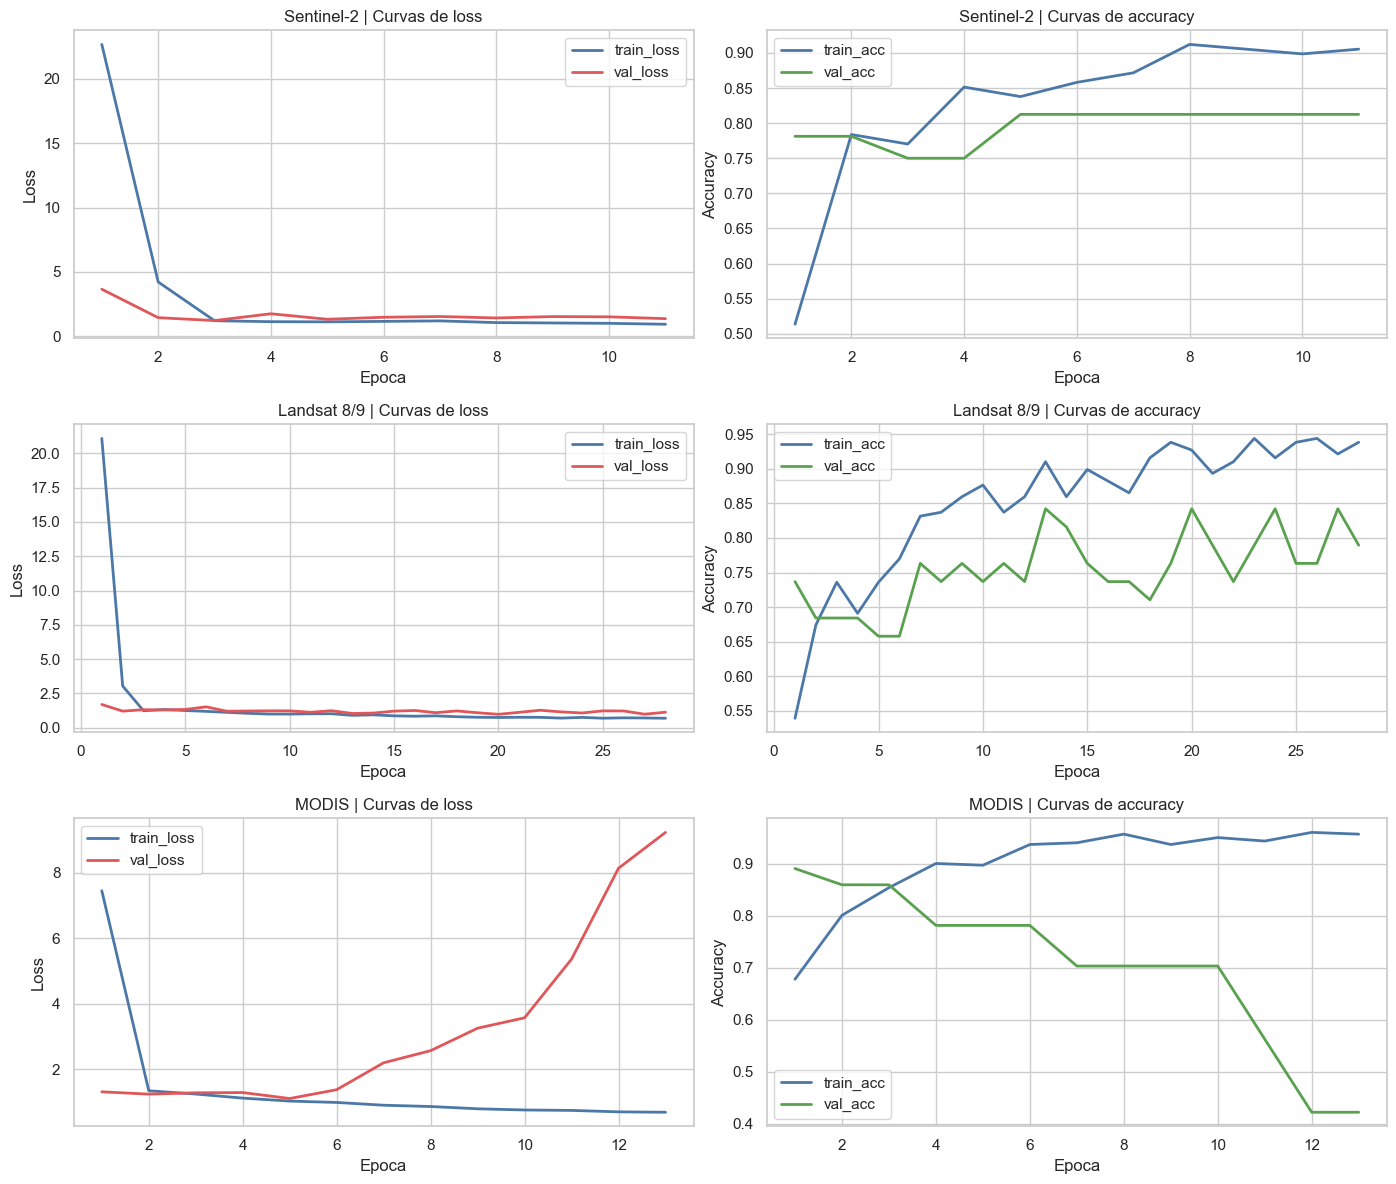

- Sentinel-2 combina boa acuracia de teste com o menor gap final entre treino e validacao.
- Landsat 8/9 mantem curva mais longa e melhora gradual, mas ainda fecha com gap perceptivel.
- MODIS exibe o pior comportamento de generalizacao: a acuracia de treino sobe enquanto a validacao degrada rapidamente.

In [6]:
history_summary_rows = []
for sensor_key in SENSOR_ORDER:
    item = artifacts[sensor_key]
    hist = item["history"].copy()
    hist.index = np.arange(1, len(hist) + 1)
    best_epoch_acc = int(hist["val_accuracy"].idxmax())
    best_epoch_loss = int(hist["val_loss"].idxmin())
    history_summary_rows.append(
        {
            "sensor": item["sensor_name"],
            "epochs_ran": item["metrics"]["epochs_ran"],
            "best_epoch_val_acc": best_epoch_acc,
            "best_val_acc": hist["val_accuracy"].max(),
            "best_epoch_val_loss": best_epoch_loss,
            "best_val_loss": hist["val_loss"].min(),
            "final_train_acc": hist["accuracy"].iloc[-1],
            "final_val_acc": hist["val_accuracy"].iloc[-1],
            "gap_train_minus_val_acc": item["metrics"]["generalization_gap_train_minus_val_acc"],
        }
    )

history_summary_df = pd.DataFrame(history_summary_rows).sort_values("sensor", ignore_index=True)
display(history_summary_df)

fig, axes = plt.subplots(len(SENSOR_ORDER), 2, figsize=(14, 4 * len(SENSOR_ORDER)))
for row_idx, sensor_key in enumerate(SENSOR_ORDER):
    item = artifacts[sensor_key]
    hist = item["history"].copy()
    hist.index = np.arange(1, len(hist) + 1)

    ax_loss = axes[row_idx, 0]
    ax_acc = axes[row_idx, 1]

    ax_loss.plot(hist.index, hist["loss"], label="train_loss", linewidth=2, color="#4C78A8")
    ax_loss.plot(hist.index, hist["val_loss"], label="val_loss", linewidth=2, color="#E15759")
    ax_loss.set_title(f"{item['sensor_name']} | Curvas de loss")
    ax_loss.set_xlabel("Epoca")
    ax_loss.set_ylabel("Loss")
    ax_loss.legend()

    ax_acc.plot(hist.index, hist["accuracy"], label="train_acc", linewidth=2, color="#4C78A8")
    ax_acc.plot(hist.index, hist["val_accuracy"], label="val_acc", linewidth=2, color="#59A14F")
    ax_acc.set_title(f"{item['sensor_name']} | Curvas de accuracy")
    ax_acc.set_xlabel("Epoca")
    ax_acc.set_ylabel("Accuracy")
    ax_acc.legend()

plt.tight_layout()
plt.show()

training_notes = [
    "- Sentinel-2 combina boa acuracia de teste com o menor gap final entre treino e validacao.",
    "- Landsat 8/9 mantem curva mais longa e melhora gradual, mas ainda fecha com gap perceptivel.",
    "- MODIS exibe o pior comportamento de generalizacao: a acuracia de treino sobe enquanto a validacao degrada rapidamente.",
]
display(Markdown("\n".join(training_notes)))

## 7) Avaliacao quantitativa e comparacao com o baseline MLP

A comparacao com o baseline MLP da Sprint 2 entra por meio do arquivo `cnn_multissatelite_comparison.csv`, que ja traz a acuracia de referencia do MLP e o delta `CNN - MLP` por sensor.

Limite da comparacao:
- o artefato final salvo em `outputs/final` concentra a referencia do MLP principalmente em acuracia;
- por isso, a comparacao mais forte neste notebook fica em acuracia, F1 e AUC apenas do lado da CNN.

,sensor,cnn_accuracy,cnn_f1,cnn_roc_auc,cnn_pr_auc,cnn_balanced_accuracy,generalization_gap,epochs_ran,train_time_s,mlp_accuracy_sprint2,delta_acc_cnn_minus_mlp
0,Landsat 8/9,0.846154,0.896552,0.852071,0.849442,0.769231,0.148729,28,399.078680,0.813559,0.032595
1,MODIS,0.769231,0.842105,0.716912,0.859810,0.710784,0.534936,13,188.968475,0.813559,-0.044329
2,Sentinel-2,0.843750,0.893617,0.877273,0.941475,0.777273,0.092905,11,92.725890,0.813559,0.030191


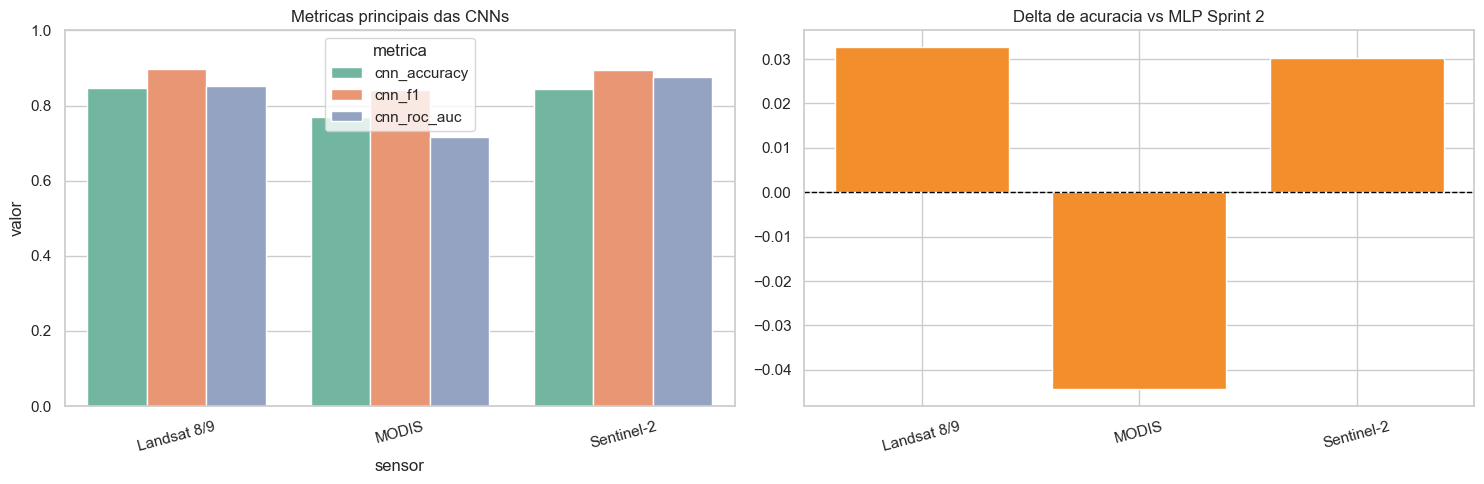

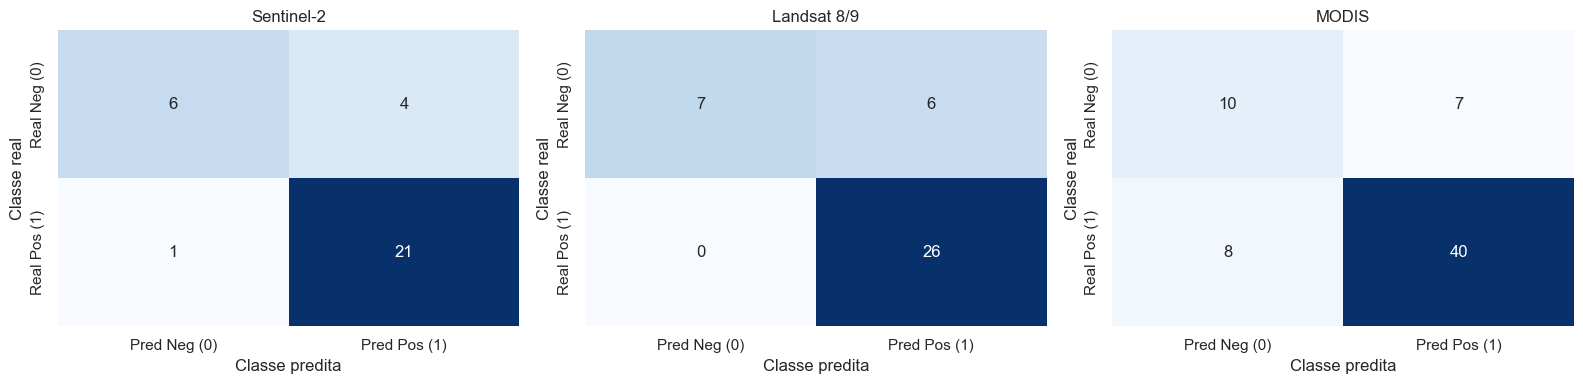

,sensor,tn,fp,fn,tp,specificity,sensitivity
0,Landsat 8/9,7,6,0,26,0.538462,1.000000
1,MODIS,10,7,8,40,0.588235,0.833333
2,Sentinel-2,6,4,1,21,0.600000,0.954545


### Leitura rapida dos artefatos finais
- Sentinel-2: indicio de overfitting (gap=0.0929).
- Sentinel-2: ganho de +0.0302 em acuracia vs MLP Sprint 2.
- Landsat 8/9: indicio de overfitting (gap=0.1487).
- Landsat 8/9: ganho de +0.0326 em acuracia vs MLP Sprint 2.
- MODIS: indicio de overfitting (gap=0.5349).
- MODIS: queda de -0.0443 em acuracia vs MLP Sprint 2.
- Melhor F1: Landsat 8/9 (0.8966).
- Limitacao: o baseline MLP salvo no projeto possui poucas metricas detalhadas; a comparacao principal ficou concentrada em acuracia/loss.

In [7]:
comparison_view = comparison_df.copy()
comparison_view["sensor"] = comparison_view["sensor_key"].map(SENSOR_NAMES)
comparison_view = comparison_view[
    [
        "sensor",
        "cnn_accuracy",
        "cnn_f1",
        "cnn_roc_auc",
        "cnn_pr_auc",
        "cnn_balanced_accuracy",
        "generalization_gap",
        "epochs_ran",
        "train_time_s",
        "mlp_accuracy_sprint2",
        "delta_acc_cnn_minus_mlp",
    ]
].sort_values("sensor", ignore_index=True)
display(comparison_view)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
metrics_plot_df = comparison_view.melt(
    id_vars="sensor",
    value_vars=["cnn_accuracy", "cnn_f1", "cnn_roc_auc"],
    var_name="metrica",
    value_name="valor",
)
if sns is not None:
    sns.barplot(data=metrics_plot_df, x="sensor", y="valor", hue="metrica", ax=axes[0], palette="Set2")
else:
    pivot_metrics = metrics_plot_df.pivot(index="sensor", columns="metrica", values="valor")
    pivot_metrics.plot(kind="bar", ax=axes[0])
axes[0].set_ylim(0, 1.0)
axes[0].set_title("Metricas principais das CNNs")
axes[0].tick_params(axis="x", rotation=15)

axes[1].bar(comparison_view["sensor"], comparison_view["delta_acc_cnn_minus_mlp"], color="#F28E2B")
axes[1].axhline(0.0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Delta de acuracia vs MLP Sprint 2")
axes[1].tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

confusion_rate_rows = []
fig, axes = plt.subplots(1, len(SENSOR_ORDER), figsize=(16, 4))
for idx, sensor_key in enumerate(SENSOR_ORDER):
    item = artifacts[sensor_key]
    cm = item["confusion"].to_numpy(dtype=int)
    tn, fp = cm[0]
    fn, tp = cm[1]
    specificity = tn / (tn + fp) if (tn + fp) else np.nan
    sensitivity = tp / (tp + fn) if (tp + fn) else np.nan
    confusion_rate_rows.append(
        {
            "sensor": item["sensor_name"],
            "tn": tn,
            "fp": fp,
            "fn": fn,
            "tp": tp,
            "specificity": specificity,
            "sensitivity": sensitivity,
        }
    )

    ax = axes[idx]
    if sns is not None:
        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=["Pred Neg (0)", "Pred Pos (1)"],
            yticklabels=["Real Neg (0)", "Real Pos (1)"],
            cbar=False,
            ax=ax,
        )
    else:
        ax.imshow(cm, cmap="Blues")
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                ax.text(j, i, int(cm[i, j]), ha="center", va="center", color="black")
        ax.set_xticks([0, 1], ["Pred Neg (0)", "Pred Pos (1)"])
        ax.set_yticks([0, 1], ["Real Neg (0)", "Real Pos (1)"])
    ax.set_title(item["sensor_name"])
    ax.set_xlabel("Classe predita")
    ax.set_ylabel("Classe real")

plt.tight_layout()
plt.show()

confusion_rates_df = pd.DataFrame(confusion_rate_rows).sort_values("sensor", ignore_index=True)
display(confusion_rates_df)

analysis_markdown = ["### Leitura rapida dos artefatos finais"]
analysis_markdown.extend(f"- {line}" for line in analysis_lines)
display(Markdown("\n".join(analysis_markdown)))

## 8) Analise critica dos resultados

Esta secao fecha o A05 conectando os resultados das CNNs com as hipoteses ja levantadas nos notebooks exploratorios.

In [8]:
synthesis_rows = []
for sensor_key in SENSOR_ORDER:
    item = artifacts[sensor_key]
    band_df = item["band_summary"].copy()
    idx_df = item["index_summary"].copy()
    metrics = item["metrics"]["classification_metrics_test"]
    cmp_row = comparison_df.loc[comparison_df["sensor_key"].eq(sensor_key)].iloc[0]
    top_bands = ", ".join(
        band_df.sort_values("std", ascending=False).head(3)["band"].astype(str).tolist()
    )
    ndvi_row = idx_df.loc[idx_df["index_name"].eq("NDVI")]
    ndvi_mean = float(ndvi_row["mean"].iloc[0]) if not ndvi_row.empty else np.nan
    synthesis_rows.append(
        {
            "sensor": item["sensor_name"],
            "top_bandas_variabilidade": top_bands,
            "ndvi_mean": ndvi_mean,
            "cnn_accuracy": metrics["accuracy"],
            "cnn_f1": metrics["f1"],
            "gap_train_minus_val_acc": item["metrics"]["generalization_gap_train_minus_val_acc"],
            "delta_vs_mlp_accuracy": cmp_row["delta_acc_cnn_minus_mlp"],
            "hipotese_1": item["hypotheses"][0] if item["hypotheses"] else "",
        }
    )

synthesis_df = pd.DataFrame(synthesis_rows).sort_values("sensor", ignore_index=True)
display(synthesis_df)

compiled_hypotheses_md = ["### Hipoteses consolidadas vindas da exploracao final"]
compiled_hypotheses_md.extend(f"- {line}" for line in compiled_hypotheses)
display(Markdown("\n".join(compiled_hypotheses_md)))

best_acc_sensor = comparison_df.sort_values("cnn_accuracy", ascending=False).iloc[0]
best_f1_sensor = comparison_df.sort_values("cnn_f1", ascending=False).iloc[0]
worst_gap_sensor = comparison_df.sort_values("generalization_gap", ascending=False).iloc[0]
negative_delta = comparison_df.loc[comparison_df["delta_acc_cnn_minus_mlp"] < 0, "sensor_key"].map(SENSOR_NAMES).tolist()
positive_delta = comparison_df.loc[comparison_df["delta_acc_cnn_minus_mlp"] > 0, "sensor_key"].map(SENSOR_NAMES).tolist()

critical_points = [
    "### Sintese critica",
    f"- Melhor acuracia de teste: **{SENSOR_NAMES[best_acc_sensor['sensor_key']]}** ({best_acc_sensor['cnn_accuracy']:.4f}).",
    f"- Melhor F1 de teste: **{SENSOR_NAMES[best_f1_sensor['sensor_key']]}** ({best_f1_sensor['cnn_f1']:.4f}).",
    f"- Maior indicio de overfitting: **{SENSOR_NAMES[worst_gap_sensor['sensor_key']]}** (gap={worst_gap_sensor['generalization_gap']:.4f}).",
    f"- Sensores acima do baseline MLP em acuracia: {', '.join(positive_delta) if positive_delta else 'nenhum'}.",
    f"- Sensores abaixo do baseline MLP em acuracia: {', '.join(negative_delta) if negative_delta else 'nenhum'}.",
    "- O comportamento de MODIS reforca as hipoteses de redundancia espectral e necessidade de regularizacao/normalizacao mais forte por sensor.",
    "- Sentinel-2 e Landsat 8/9 sustentam a tese de que a CNN simples aproveita bem a estrutura espacial do tile mesmo sem complexidade arquitetural alta.",
    "- A matriz de confusao mostra uma tendencia geral a privilegiar a classe positiva, coerente com o desbalanceamento observado na preparacao dos dados.",
    "- Como nao ha notebook final versionado para o treino multissatellite, a reprodutibilidade desta parte fica ancorada nos arquivos exportados, nao no pipeline narrado passo a passo.",
]
display(Markdown("\n".join(critical_points)))

,sensor,top_bandas_variabilidade,ndvi_mean,cnn_accuracy,cnn_f1,gap_train_minus_val_acc,delta_vs_mlp_accuracy,hipotese_1
0,Landsat 8/9,"B7, B5, B4",-0.086193,0.846154,0.896552,0.148729,0.032595,"Bandas com maior variabilidade (B7, B5, B4) po..."
1,MODIS,"B2, B5, B1",0.481508,0.769231,0.842105,0.534936,-0.044329,"Bandas com maior variabilidade (B2, B5, B1) po..."
2,Sentinel-2,"B11, B12, B9",0.466896,0.843750,0.893617,0.092905,0.030191,"Bandas com maior variabilidade (B11, B12, B9) ..."


### Hipoteses consolidadas vindas da exploracao final
- O sensor com maior volume de pixels e modis; testar estrategias de balanceamento na etapa integrada.
- Landsat 89 apresentou maior taxa media de faltantes nas bandas; avaliar imputacao/mascara especifica por sensor.
- As medias de NDVI variam entre sensores; testar normalizacao por sensor antes de treinar modelos unificados.

### Sintese critica
- Melhor acuracia de teste: **Landsat 8/9** (0.8462).
- Melhor F1 de teste: **Landsat 8/9** (0.8966).
- Maior indicio de overfitting: **MODIS** (gap=0.5349).
- Sensores acima do baseline MLP em acuracia: Sentinel-2, Landsat 8/9.
- Sensores abaixo do baseline MLP em acuracia: MODIS.
- O comportamento de MODIS reforca as hipoteses de redundancia espectral e necessidade de regularizacao/normalizacao mais forte por sensor.
- Sentinel-2 e Landsat 8/9 sustentam a tese de que a CNN simples aproveita bem a estrutura espacial do tile mesmo sem complexidade arquitetural alta.
- A matriz de confusao mostra uma tendencia geral a privilegiar a classe positiva, coerente com o desbalanceamento observado na preparacao dos dados.
- Como nao ha notebook final versionado para o treino multissatellite, a reprodutibilidade desta parte fica ancorada nos arquivos exportados, nao no pipeline narrado passo a passo.

## 9) Fechamento

O notebook consolidado abaixo fecha o A05 em formato pronto para entrega: a preparacao, a arquitetura, o treino, a avaliacao e a analise critica foram reorganizados em torno dos artefatos finais do projeto.

In [9]:
delivery_checklist_df = pd.DataFrame(
    [
        {
            "item_enunciado": "Preparacao dos dados para CNN",
            "status": "OK",
            "evidencia_no_notebook": "Secao 4 com data_prep_summary, split_summary e comparacao dataset longo vs rotulado",
        },
        {
            "item_enunciado": "Implementacao da arquitetura CNN",
            "status": "OK",
            "evidencia_no_notebook": "Secao 5 com architecture_summary e tabela de camadas",
        },
        {
            "item_enunciado": "Treinamento e validacao",
            "status": "OK",
            "evidencia_no_notebook": "Secao 6 com history.csv, curvas e gaps de generalizacao",
        },
        {
            "item_enunciado": "Avaliacao quantitativa e comparacao com MLP",
            "status": "OK",
            "evidencia_no_notebook": "Secao 7 com comparison.csv, matrizes de confusao e delta vs MLP",
        },
        {
            "item_enunciado": "Analise critica",
            "status": "OK",
            "evidencia_no_notebook": "Secao 8 com sintese por sensor, hipoteses consolidadas e limitacoes",
        },
    ]
)
display(delivery_checklist_df)

closing_notes = [
    "### Limitacoes que precisam ficar explicitas na apresentacao",
    "- O baseline MLP aparece no artefato final principalmente como referencia de acuracia da Sprint 2.",
    "- Os resultados de `a05_cnn_multissatelite` foram importados de `outputs/final`, sem notebook final correspondente na pasta `notebooks/final`.",
    "- Mesmo com essas limitacoes, o encadeamento exploracao -> modelagem -> avaliacao ficou consistente e rastreavel dentro do repositorio.",
]
display(Markdown("\n".join(closing_notes)))

,item_enunciado,status,evidencia_no_notebook
0,Preparacao dos dados para CNN,OK,"Secao 4 com data_prep_summary, split_summary e..."
1,Implementacao da arquitetura CNN,OK,Secao 5 com architecture_summary e tabela de c...
2,Treinamento e validacao,OK,"Secao 6 com history.csv, curvas e gaps de gene..."
3,Avaliacao quantitativa e comparacao com MLP,OK,"Secao 7 com comparison.csv, matrizes de confus..."
4,Analise critica,OK,"Secao 8 com sintese por sensor, hipoteses cons..."


### Limitacoes que precisam ficar explicitas na apresentacao
- O baseline MLP aparece no artefato final principalmente como referencia de acuracia da Sprint 2.
- Os resultados de `a05_cnn_multissatelite` foram importados de `outputs/final`, sem notebook final correspondente na pasta `notebooks/final`.
- Mesmo com essas limitacoes, o encadeamento exploracao -> modelagem -> avaliacao ficou consistente e rastreavel dentro do repositorio.